In [1]:
# 소음 분석(악기 오디오 파일 분류)
# 1) 오디오 파일 읽기
# 2) waveplot 시각화
# 3) FFT 시각화
# 4) Spectrigram 생성 및 이미지 저장
# 5) CNN 분류 모델 학습
# 6) 성능 평가
# 7) 신규 오디오 예측(절대경로 입력)
# 8) 예측 결과 시각화

In [2]:
! pip install librosa Image wave

  Using cached wave-0.1.0-py3-none-any.whl.metadata (586 bytes)
  Using cached MySQL-python-1.2.5.zip (108 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [19 lines of output]
      Traceback (most recent call last):
        File "/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
        File "/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "/tmp/pip-bu

In [3]:
! pip install librosa

In [4]:
# 1. 임포트
import os           # 파일 경로처리, 디렉토리 존재 여부 검사, 파일명 분리 등에 사용
import glob         # 파일의 확장자를 구분하여 파일 목록을 수집할 때 사용
import random
import shutil       # 폴더 전체 삭제, 파일 복사 등 파일 시스템 사용 라이브러리

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 오디오 로딩, STFT, mel spectrogram, db 변환 등 오디오 시그널 프로세싱에 필요한 라이브러리
import librosa
# librosa 기반 파형/스펙트로그램 표시형 시각화 모듈
import librosa.display
# 저장된 spectrogram 이미지를 읽고, RGB 변환 및 크기 Syn에 사용
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')



I0000 00:00:1787616607.373739    8032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787616607.374528    8032 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787616607.730672    8032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787616609.319195    8032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

In [5]:
! pip install image

In [6]:
# 2. 기본 경로 및 전역 하이퍼 파라미터 설정

BASE_DIR = os.getcwd()                                    # root dir 설정
AUDIO_DIR = os.path.join(BASE_DIR, "..", "..", "sound", "audio")               # 오디오 파일이 저장된 루트 폴더
SPEC_DIR = os.path.join(BASE_DIR, "spectrogram_data")     # 오디오 이미지를 변환하여 저장할 폴더
SPLIT_DIR = os.path.join(BASE_DIR, 'spectrogram_spilt')   # CNN 학습용으로 train/val/test 구조로 나누어 저장하는 폴더
BEST_MODEL_DIR = os.path.join(BASE_DIR, "best_instrument_cnn_model.keras")    # 최종 학습 모델 파일 및 저장하는 경로
TEMP_PREDICT_IMAGE_PATH = os.path.join(BASE_DIR, 'temp_predict_spectrogram.png')    # 신규 예측시, 임시로 스펙트로그램 이미지를 저장할 경로

CLASSES = ["cello", "flute", "oboe", "sax", "trumpet", "viola"]       # 폴더명과 정확히 일치하도록 정의

# CNN 입력 이미지 높이/너비 지정
IMG_HEIGHT = 224
IMG_WIDTH = 224

# signal processing 파라미터 설정
SR = 32768                                # 샘플링 주파수
DURATION = 1.5                            # 오디오의 길이(초단위)
SAMPLES_PER_TRACK = int(SR * DURATION)         # 1개의 오디오 샘플당 기대되는 총 샘플 수
N_FFT = 4096                              # 멜 스펙트로그램 생성 시, 사용할 FFT 윈도우 길이
HOP_LENGTH = 128                         # 프레인 간 HOP 크기(값이 작을수로 시간 해상도 증가)
N_MELS = 128                              # MEL Filter Bank 개수 (너무 작으면 정보 깨지고, 너무 크면 이미지 복잡해짐)

# 학습 파라미터 설정
BATCH_SIZE = 16                           
EPOCHS = 20

In [7]:
# 3. 유효성 검사 및 공통 유틸리티 함수
def ensure_directory_exists(dir_path):
    """
    지정한 디렉토리가 존재하지 않으면 생성
    """
    os.makedirs(dir_path, exist_ok=True)


def validate_audio_directory_structure(audio_dir, classes):
    """
    audio 폴더와 클래스별 하위 폴더가 존재하는지 확인
    """
    if not os.path.exists(audio_dir):
        raise FileNotFoundError(f"[오류] audio 루트 폴더를 찾을 수 없습니다: {audio_dir}")

    for cls in classes:
        class_dir = os.path.join(audio_dir, cls)
        if not os.path.exists(class_dir):
            raise FileNotFoundError(f"[오류] 클래스 폴더가 없습니다: {class_dir}")


def count_audio_files(audio_dir, classes, extension="*.mp3"):
    """
    클래스별 오디오 파일 개수를 집계하여 dict 형태로 반환
    """
    counts = {}
    for cls in classes:
        pattern = os.path.join(audio_dir, cls, extension)
        counts[cls] = len(glob.glob(pattern))
    return counts


def validate_minimum_files_per_class(file_counts, minimum_count=3):
    """
    각 클래스에 최소 개수 이상의 파일이 존재하는지 검증
    """
    for cls, count in file_counts.items():
        if count < minimum_count:
            raise ValueError(
                f"[오류] 클래스 '{cls}'의 파일 수가 너무 적습니다. "
                f"최소 {minimum_count}개 이상 필요하지만 현재 {count}개입니다."
            )


def safe_remove_path(path):
    """
    파일 또는 디렉토리가 존재할 때만 삭제
    """
    if os.path.isdir(path):
        shutil.rmtree(path)
    elif os.path.isfile(path):
        os.remove(path)


def print_section_title(title):
    """
    노트북에서 섹션 구분이 명확하게 보이도록 제목 출력
    """
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)


데이터 폴더 및 파일 개수 확인
원본 오디오 루트 경로 :  /home/pc/study_archive/ai/2026/08/24/../../sound/audio
스펙트로그램 저장 경로 :  /home/pc/study_archive/ai/2026/08/24/spectrogram_data
분할 데이터 저장 경로 :  /home/pc/study_archive/ai/2026/08/24/spectrogram_spilt
     Class  Count
0    cello    100
1    flute    100
2     oboe    100
3      sax    100
4  trumpet    100
5    viola    100


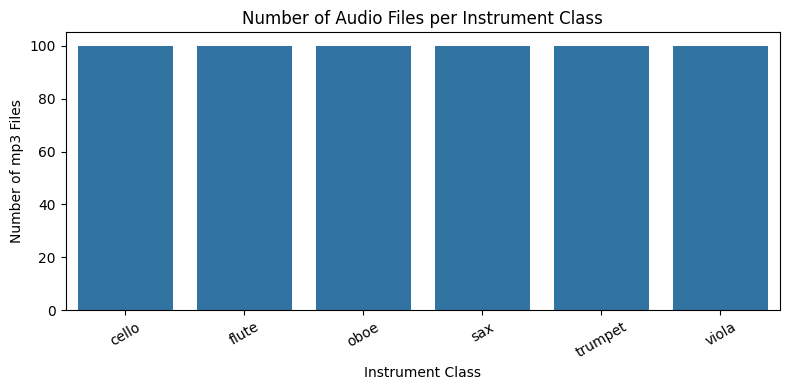

In [8]:
# 4. 데이터 폴더 구조 및 파일 개수 확인

# 오디오 폴더 및 하위 폴더 존재 여부 확인
validate_audio_directory_structure(AUDIO_DIR, CLASSES)

# 클래스별 mp3 파일 개수 확인
file_counts = count_audio_files(AUDIO_DIR, CLASSES, extension="*.mp3")

# 각 클래스가 최소한의 샘풀 수를 갖는지 확인
validate_minimum_files_per_class(file_counts, minimum_count=10)

# 집계 결과를 데이터프레임으로 변환
file_counts_df = pd.DataFrame(list(file_counts.items()), columns=["Class", "Count"])

# 현재 데이터 구성 상황 확인
print_section_title("데이터 폴더 및 파일 개수 확인")
print("원본 오디오 루트 경로 : ", AUDIO_DIR)
print("스펙트로그램 저장 경로 : ", SPEC_DIR)
print("분할 데이터 저장 경로 : ", SPLIT_DIR)
print(file_counts_df)

plt.figure(figsize=(8,4))
sns.barplot(data=file_counts_df, x="Class", y="Count")
plt.title("Number of Audio Files per Instrument Class")
plt.xlabel("Instrument Class")
plt.ylabel("Number of mp3 Files")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [9]:
# 5. 오디오 로드 함수 정의
def load_audio_file(file_path, sr=SR, duration=DURATION):
    """
    오디오 파일을 모노 신호로 읽고, 지정 길이로 고정한다.

    설계 의도:
    - 모델 입력 일관성을 위해 모든 오디오 길이를 동일하게 맞춘다.
    - 너무 짧은 파일은 zero-padding한다.
    - 너무 긴 파일은 앞부분을 사용한다.
    - mp3 코덱 또는 파일 경로 문제를 조기에 감지할 수 있도록 예외를 명확히 전달한다.
    """

    # 입력 경로가 문자열인지 확인한다.
    if not isinstance(file_path, str):
        raise TypeError(f"[오류] file_path는 문자열이어야 합니다. 현재 타입: {type(file_path)}")

    # 실제 파일 존재 여부를 먼저 확인한다.
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"[오류] 오디오 파일이 존재하지 않습니다: {file_path}")

    # 파일 확장자를 확인한다. 이 실습은 mp3를 기본으로 가정하지만 wav 등으로 확장 가능하다.
    valid_exts = [".mp3", ".wav", ".flac", ".ogg", ".m4a"]
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_exts:
        raise ValueError(f"[오류] 지원하지 않는 오디오 확장자입니다: {ext}")

    try:
        # mono=True는 스테레오 입력을 단일 채널로 평균/변환하여 처리 일관성을 확보한다.
        y, sr = librosa.load(file_path, sr=sr, mono=True)
    except Exception as e:
        raise RuntimeError(f"[오류] 오디오 로드 실패: {file_path}\n원인: {e}")

    # 비어 있는 배열이 들어오면 이후 FFT/STFT에서 실패하므로 사전 차단한다.
    if y is None or len(y) == 0:
        raise ValueError(f"[오류] 오디오 데이터가 비어 있습니다: {file_path}")

    # 목표 샘플 길이를 계산한다.
    target_length = int(sr * duration)

    # 길이가 짧으면 뒤를 0으로 패딩하여 고정 길이를 맞춘다.
    if len(y) < target_length:
        pad_width = target_length - len(y)
        y = np.pad(y, (0, pad_width), mode='constant')

    # 길이가 길면 앞부분만 사용한다.
    else:
        y = y[:target_length]

    return y, sr

In [10]:
# 6. 샘플 오디오 파일 1개 선택 및 기본 분석

# 대이터 시각화 예제로 사용할 첫 번째 샘플 파일을 찾음
sample_file = None
sample_class = None

for cls in CLASSES:
  pattern = os.path.join(AUDIO_DIR, cls, "*.mp3")
  files = glob.glob(pattern)
  if len(files) > 0:
    sample_file = files[0]
    sample_class = cls
    break

if sample_file is None:
  raise FileNotFoundError("[오류] 샘플로 사용할 mp3 파일을 찾지 못했습니다.")

# 샘플 파일 로드
y_sample, sr_sample = load_audio_file(sample_file)

# 샘플 파일 정보 출력
print("샘플 클래스: ", sample_class)
print("샘플 파일 : ", sample_file)
print("샘플링 주파수", sr_sample)
print("총 샘플 수 : ", len(y_sample))
print("총 길이 : ", len(y_sample) / sr_sample)

샘플 클래스:  cello
샘플 파일 :  /home/pc/study_archive/ai/2026/08/24/../../sound/audio/cello/cello_A3_15_forte_arco-normal.mp3
샘플링 주파수 32768
총 샘플 수 :  49152
총 길이 :  1.5


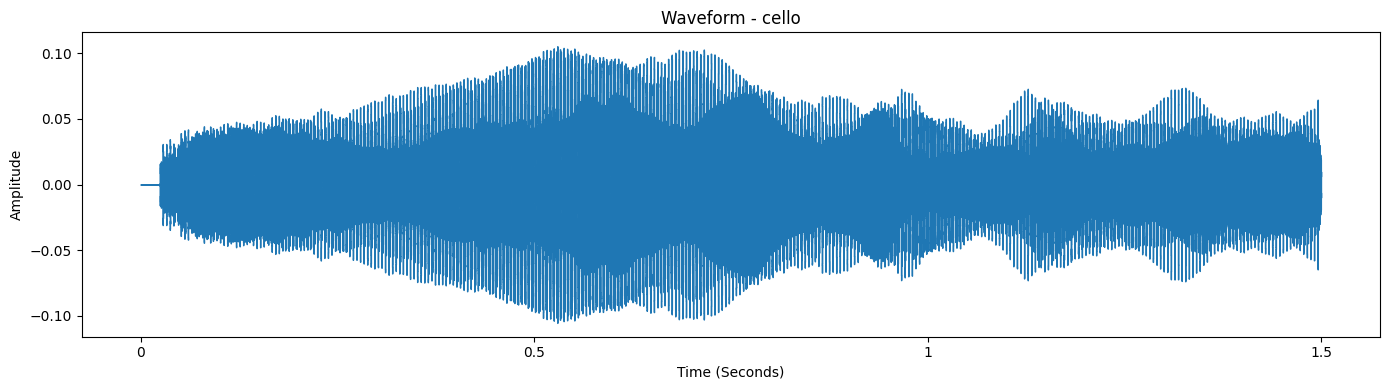

In [11]:
# 7. 샘플 오디오 waveplot 시각화
plt.figure(figsize=(14,4))
librosa.display.waveshow(y_sample, sr=sr_sample)
plt.title(f"Waveform - {sample_class}")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

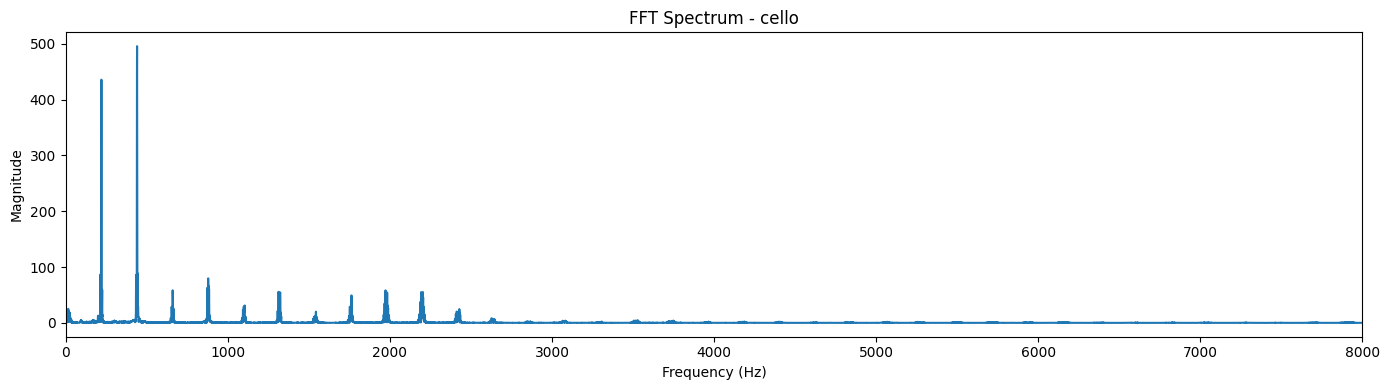

In [12]:
# 8. 샘플 오디오 FFT 시각화 
# FFT는 시간영역 신호를 주파수 영역으로 투영하여 어떤 주파수 성분이 강한지 확인
fft_sample = np.fft.fft(y_sample)

magnitude_sample = np.abs(fft_sample)

# 각 인덱스가 실제 어떤 주파수(Hz)에 대응하는지 계산
freqs_sample = np.fft.fftfreq(len(magnitude_sample), d=1 / sr_sample)

# 실수 신호 FFT는 음수 주파수 구간이 대칭이므로 양수 영역만 사용
positive_freqs_sample = freqs_sample[:len(freqs_sample) // 2]
positive_magnitude_sample = magnitude_sample[:len(magnitude_sample) // 2]

#(위 함수 상세 설명은 어려우니 시간영영 신호를 주파수 로 변환한다고만 생각)

# 저주파~중주파 영역을 주로 보기 위해 x축을 적절히 제한
plt.figure(figsize=(14, 4))
plt.plot(positive_freqs_sample, positive_magnitude_sample)
plt.title(f"FFT Spectrum - {sample_class}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 8000)
plt.tight_layout()
plt.show()


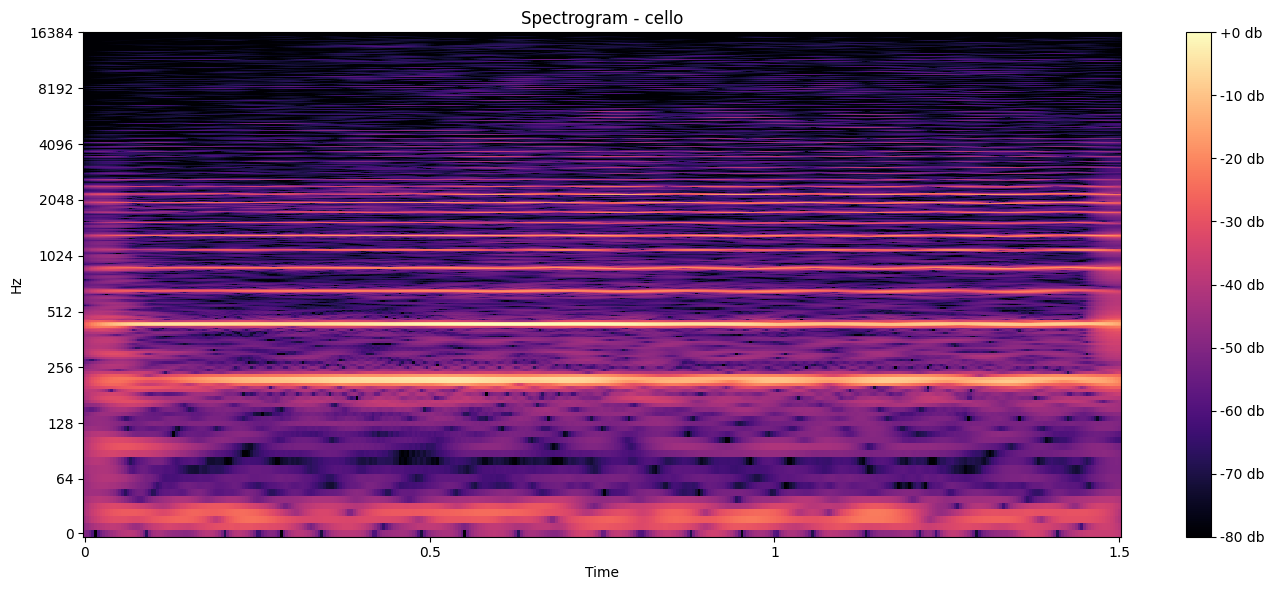

In [13]:
# 9. 샘플 오디오 STFT spectrogram 시각화

# STFT는 짧은 시간 구간별로 FFT를 수행하여 시간-주파수 2차원 표현으로 생성
stft_sample = librosa.stft(y_sample, n_fft=N_FFT, hop_length=HOP_LENGTH)

# 복소수 stft 결과의 절대값을 취하여 magnitude spectrogram 생성
spectrogram_sample = np.abs(stft_sample)

# 사람의 청각 및 신호 에너지 해석에 유리하도록 DB 스케일로 변환
spectrogram_db_sample = librosa.amplitude_to_db(spectrogram_sample, ref=np.max)

# 로그 주파수축 spectrogram 을 그린다.
plt.figure(figsize=(14, 6))

librosa.display.specshow(
    spectrogram_db_sample,
    sr=sr_sample,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="log",
    cmap="magma"
)

plt.colorbar(format='%+2.0f db')
plt.title(f"Spectrogram - {sample_class}")
plt.tight_layout()
plt.show()



In [14]:
# 10. Spectrogram 이미지 저장 함수

def save_spectrogram_image(audio_path, save_path, sr=SR, duration=DURATION):
  save_dir = os.path.dirname(save_path)

  if save_dir != "":
    ensure_directory_exists(save_dir)

  # 오디오 로드
  y, sr = load_audio_file(audio_path, sr=sr, duration=duration)

  # met spectrogram 계산
  mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    power=2.0
  )

  mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

  fig=plt.figure(figsize=(4,4))

  # 축/눈금 없이 순수한 스펙트럼 패턴만 저장되도록 그린다.
  librosa.display.specshow(
    mel_spec_db, 
    sr=sr,
    hop_length=HOP_LENGTH,
    x_axis=None,
    y_axis=None,
    cmap = 'magma'
  )

  plt.axis('off')   # CNN이 의미 없는 축 텍스트를ㄹ 학습하지 않도록 축 제거
  plt.tight_layout(pad=0)   # 이미지 저장시 여백 최소화

  plt.savefig(save_path, bbox_inches='tight', pad_inches=0)     # png로 저장
  plt.close(fig)    # 메모리 부하를 방지 하기위해 figure를 닫는다

  # 저장된 이미지를 열어 RGB 변환 후 입력 크기로 통일
  img = Image.open(save_path).convert("RGB")
  img = img.resize((IMG_WIDTH, IMG_HEIGHT))
  img.save(save_path)



In [15]:
# 11. 전체 오디오 파일 -> Spectrogram 이미지 생성
# 이전 실행 결과가 남아 있으면 삭제하여 중복/오염을 방지
safe_remove_path(SPEC_DIR)

# spectrogram 루트 폴더를 생성
ensure_directory_exists(SPEC_DIR)

print_section_title("스펙트로그램 이미지 생성 시작")

# 클래스별로 모든 mp3를 순회하면서 spectrogram 이미지를 생성
for cls in CLASSES:
    class_audio_dir = os.path.join(AUDIO_DIR, cls)
    class_spec_dir = os.path.join(SPEC_DIR, cls)

    # 클래스별 spectrogram 저장 폴더를 생성
    ensure_directory_exists(class_spec_dir)

    # 해당 클래스의 mp3 목록을 가져오기
    audio_files = glob.glob(os.path.join(class_audio_dir, "*.mp3"))

    # 처리 현황을 출력
    print(f"{cls}: {len(audio_files)}개 파일 처리 중...")

    # 각 파일을 spectrogram으로 변환
    for audio_file in audio_files:
        base_name = os.path.splitext(os.path.basename(audio_file))[0]
        save_path = os.path.join(class_spec_dir, f"{base_name}.png")
        save_spectrogram_image(audio_file, save_path)

print("스펙트로그램 이미지 생성 완료")


스펙트로그램 이미지 생성 시작
cello: 100개 파일 처리 중...
flute: 100개 파일 처리 중...
oboe: 100개 파일 처리 중...
sax: 100개 파일 처리 중...
trumpet: 100개 파일 처리 중...
viola: 100개 파일 처리 중...
스펙트로그램 이미지 생성 완료


In [16]:
# 12. Train/val/test 분할 함수
def split_dataset_to_folders(source_dir, target_dir, classes, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
  # 스펙트로그램 이미지를 클래스 별 train/val/test 폴더 구조로 분할

  # 기존 split 폴더 삭제
  safe_remove_path(target_dir)

  # 비율의 합이 1인지 검증
  if abs(train_ratio + val_ratio + test_ratio - 1.0) >= 1e-6:
    raise ValueError("[오류] train_ratio + val_ratio + test_ratio 의 합은 반드시 1이어야 함")

  for cls in classes:
    class_dir = os.path.join(source_dir, cls)

    # 원본 클래스 이미지가 존재하는지 확인
    if not os.path.exists(class_dir):
      raise FileNotFoundError(f"[오류] spectrogram 클래스 폴더가 없습니다: {class_dir}")

    image_files = glob.glob(os.path.join(class_dir, "*.png"))

    if len(image_files) == 0:
      raise ValueError(f"[오류] 클래스 '{cls}' 의 스펙트로그램 이미지가 없습니다.")

    # 무작위 셔플 후 분할
    random.shuffle(image_files)

    n_total = len(image_files)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_files = image_files[:n_train]
    val_files = image_files[n_train: n_train + n_val]
    test_files = image_files[n_train + n_val:]

    # split 별 폴더 생성
    for split_name in ["train","val","test"]:
      ensure_directory_exists(os.path.join(target_dir, split_name, cls))

    # 복사 함수
    def copy_files(files, split_name):
      for f in files:
        dst = os.path.join(target_dir, split_name, cls, os.path.basename(f))
        shutil.copy(f, dst)

    copy_files(train_files, "train")
    copy_files(val_files, "val")
    copy_files(test_files, "test")

    print(f"{cls} -> train:{len(train_files)}, val:{len(val_files)}, test: {len(test_files)}")

# split 이후 각 train/val/test/class 폴더에 최소 1개 이상의 이미지가 있는지 검증
def validate_split_dataset(target_dir, classes):
    """
    split 이후 각 train/val/test/class 폴더에 최소 1개 이상의 이미지가 있는지 검증한다.
    """
    print_section_title("분할 데이터셋 검증")
    for split_name in ["train", "val", "test"]:
        print(f"[{split_name}]")
        for cls in classes:
            class_dir = os.path.join(target_dir, split_name, cls)
            count = len(glob.glob(os.path.join(class_dir, "*.png")))
            print(f"  {cls}: {count}개")
            if count == 0:
                raise ValueError(
                    f"[오류] {split_name}/{cls} 폴더에 이미지가 없습니다. "
                    f"클래스별 샘플 수가 너무 적거나 분할 비율 조정이 필요합니다."
                )



In [17]:
# 13. 데이터셋 분할 함수 실행
print_section_title("train / val / test 분할 시작")
split_dataset_to_folders(SPEC_DIR, SPLIT_DIR, CLASSES, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
validate_split_dataset(SPLIT_DIR, CLASSES)
print("데이터 분할 완료")


train / val / test 분할 시작
cello -> train:70, val:15, test: 15
flute -> train:70, val:15, test: 15
oboe -> train:70, val:15, test: 15
sax -> train:70, val:15, test: 15
trumpet -> train:70, val:15, test: 15
viola -> train:70, val:15, test: 15

분할 데이터셋 검증
[train]
  cello: 70개
  flute: 70개
  oboe: 70개
  sax: 70개
  trumpet: 70개
  viola: 70개
[val]
  cello: 15개
  flute: 15개
  oboe: 15개
  sax: 15개
  trumpet: 15개
  viola: 15개
[test]
  cello: 15개
  flute: 15개
  oboe: 15개
  sax: 15개
  trumpet: 15개
  viola: 15개
데이터 분할 완료


In [18]:
# 14. ImageDataGenerator 설정
# 학습 데이터는 약한 수준의 augmentation을 적용하여 일반화 성능을 높임
# spectrogram은 일반 사진과 의미 체계가 다르므로 회전/이동/확대 범위를 매우 작게 유지
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05
)

# 검증/테스트 데이터는 모델 평가의 일관성을 위해 정규화 수행
val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

# train generator 생성
train_generator = train_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "train"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# val generator 생성
val_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "val"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# test generator 생성
test_generator = val_test_datagen.flow_from_directory(
    directory=os.path.join(SPLIT_DIR, "test"),
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 클래스 인덱스 매핑을 출력
print_section_title("클래스 인덱스 매핑")
print(train_generator.class_indices)

# index -> class 이름 역매핑을 미리 만들어둔다.
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
print("역매핑:", idx_to_class)

Found 420 images belonging to 6 classes.
Found 90 images belonging to 6 classes.
Found 90 images belonging to 6 classes.

클래스 인덱스 매핑
{'cello': 0, 'flute': 1, 'oboe': 2, 'sax': 3, 'trumpet': 4, 'viola': 5}
역매핑: {0: 'cello', 1: 'flute', 2: 'oboe', 3: 'sax', 4: 'trumpet', 5: 'viola'}


In [19]:
# 15. CNN 모델 정의

# 입력 shape는 고정된 스펙트로그램 RGB 이미지 크기
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

# 순차형 신경망 모델  생성
model = models.Sequential()

# 첫번째 레이어 생성  <-- edge/texture 특징 추출
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
model.add(layers.MaxPool2D((2,2)))

# 두번째 레이어 생성  <-- 복잡한 주파수 리지, 하모닉 구조, 시간-주파수 패턴을 추출
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPool2D(2,2))

# 세번째 레이어 생성  <-- 중간 수준의 패턴 조합을 추출
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPool2D(2,2))

# 네번째 레이어 생성  <-- 클래스 구분력이 높은 상위 수준의 특성을 추출
model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(layers.MaxPool2D(2,2))

# 2차원 feature map을 1차원 벡터로 변환
model.add(layers.Flatten())

# Dense layer는 학습된 로컬 패턴들을 종합하여 클래스 결정 경계 형성
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))

# 최종 출력층
model.add(layers.Dense(len(CLASSES), activation='softmax'))

# 모델 구조 출력
model.summary()



E0000 00:00:1787616652.068917    8032 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787616652.098757    8032 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,270 (50.49 MB)

 Trainable params: 13,235,270 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# 16. CNN 모델 컴파일 설정

# 컴파일 설정
model.compile(
  optimizer='adam',
  loss='categorical_crossentropy',
  metrics=['accuracy']
)
# 학습 콜백 설정
early_stopping = EarlyStopping(
  monitor='val_loss',
  patience=5,
  restore_best_weights=True
)

# validation accuracy 가 최고일 때의 모델을 자동 저장
checkpoint = ModelCheckpoint(
  filepath=BEST_MODEL_DIR,
  monitor='val_accuracy',
  save_best_only=True,
  verbose=1
)

In [22]:
# 17. 모델 학습
history = model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=EPOCHS,
  callbacks=[early_stopping, checkpoint]
)

Epoch 1/20


I0000 00:00:1787617105.258398    8032 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.2086 - loss: 1.8682
Epoch 1: val_accuracy improved from None to 0.53333, saving model to /home/pc/study_archive/ai/2026/08/24/best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step - accuracy: 0.2833 - loss: 1.7321 - val_accuracy: 0.5333 - val_loss: 1.2319
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.4733 - loss: 1.3276
Epoch 2: val_accuracy improved from 0.53333 to 0.73333, saving model to /home/pc/study_archive/ai/2026/08/24/best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.5095 - loss: 1.2709 - val_accuracy: 0.7333 - val_loss: 0.8551
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.6256 - loss: 0.9303
Epoch 3: val_accuracy improved from 0.73333 to 0.85556, saving model to /home/pc/study_archive/ai/2026/08/24/best_instrument_cnn_model.keras
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.6881 - loss: 0.8100 - val_accuracy: 0.8556 -

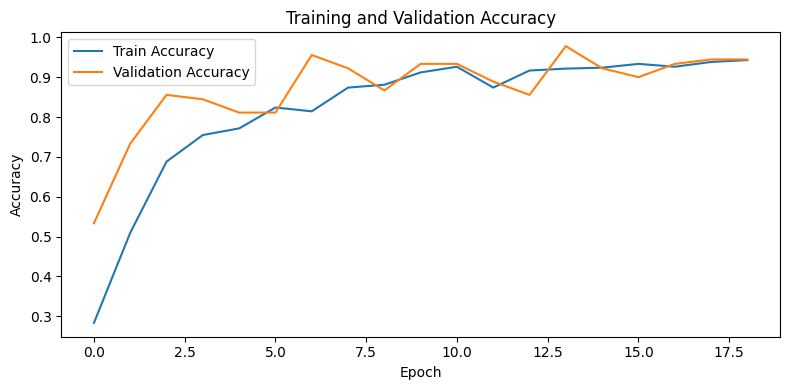

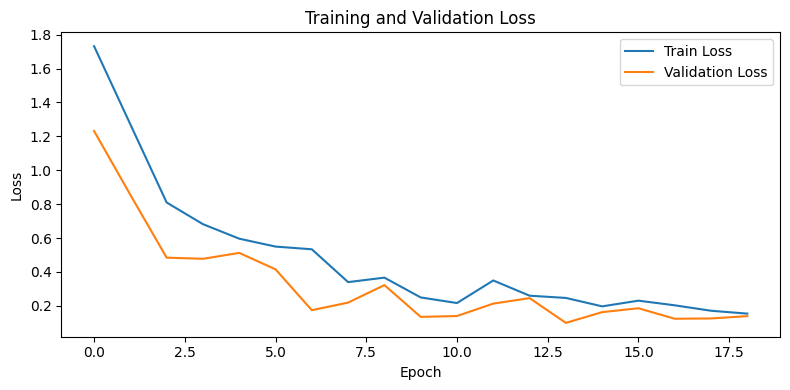

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

분류 리포트
              precision    recall  f1-score   support

       cello       1.00      0.93      0.97        15
       flute       1.00      0.93      0.97        15
        oboe       1.00      1.00      1.00        15
         sax       0.93      0.93      0.93        15
     trumpet       0.94      1.00      0.97        15
       viola       0.88      0.93      0.90        15

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



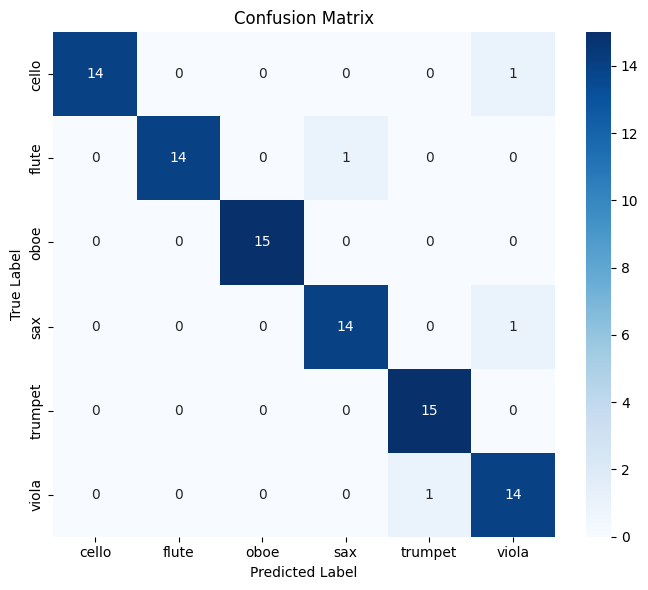

In [24]:
# 19. 분류 리포트 및 confusion Matrix
# 테스트셋 전체에 대해 클래스별 확률을 예측
pred_probs = model.predict(test_generator)

# 가장 큰 확률을 갖는 인덱스를 최종 예측 클래스로 사용
pred_classes = np.argmax(pred_probs, axis=1)

# 실제 정답 라벨
true_classes = test_generator.classes

# 클래스 이름 목록
class_labels = list(test_generator.class_indices.keys())

print_section_title("분류 리포트")
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels,
    zero_division=0
))

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [31]:
# 20. 예측된 오디오 분석/시각화 함수
def visualize_audio_analysis(audio_path, predicted_class=None, probs_dict=None):
    """
    신규 입력 오디오에 대해 waveplot, FFT, spectrogram을 순차적으로 시각화
    """

    # 오디오를 로드
    y, sr = load_audio_file(audio_path)

    # 파일명만 표시용으로 추출
    file_name = os.path.basename(audio_path)

    # 1) waveplot 시각화
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Input Audio Waveform - {file_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # 2) FFT 시각화
    fft_vals = np.fft.fft(y)
    magnitude = np.abs(fft_vals)
    freqs = np.fft.fftfreq(len(magnitude), d=1 / sr)
    positive_freqs = freqs[:len(freqs) // 2]
    positive_magnitude = magnitude[:len(magnitude) // 2]

    plt.figure(figsize=(14, 4))
    plt.plot(positive_freqs, positive_magnitude)
    plt.title(f"Input Audio FFT Spectrum - {file_name}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.xlim(0, 8000)
    plt.tight_layout()
    plt.show()

    # 3) Spectrogram 시각화
    stft = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    spectrogram = np.abs(stft)
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(12, 5))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='log'
    )
    plt.colorbar(format='%+2.0f dB')
    if predicted_class is None:
        plt.title(f"Input Audio Spectrogram - {file_name}")
    else:
        plt.title(f"Input Audio Spectrogram - {file_name}\nPredicted: {predicted_class}")
    plt.tight_layout()
    plt.show()

    # 4) 예측 확률 막대그래프
    if probs_dict is not None:
        probs_df = pd.DataFrame({
            "Class": list(probs_dict.keys()),
            "Probability": list(probs_dict.values())
        }).sort_values("Probability", ascending=False)

        plt.figure(figsize=(8, 4))
        sns.barplot(data=probs_df, x="Class", y="Probability")
        plt.title(f"Prediction Probability - {file_name}")
        plt.xlabel("Instrument Class")
        plt.ylabel("Probability")
        plt.xticks(rotation=30)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()

In [32]:
# 21. 신규 오디오 예측 함수
"""
절대 경로로 지정한 신규 오디오 파일을 읽어와 cnn으로 결과 예측
- 입력 파일 유효성 검사
- 신규 오디오 파일 -> 스팩트로그램 이미지 생성
- 모델 추론
- 예측 클래스 및 확률 반환
- 입력 오디오 waveplot / FFT / Spectrogram / 확률 시각화 수행
"""

def predict_instrument_from_audio_absolute_path(audio_path, model, class_indices, save_temp_img=False):
  # 입력값 타입 검증
  if not isinstance(audio_path, str):
    raise TypeError("[오류] audio path는 문자열이어야 합니다.")

  # 절대 경로인지 확인
  if not os.path.isabs(audio_path):
    raise ValueError(f"[오류] 신규 오디오 예측 경로는 절대경로여야 합니다.: {audio_path}")

  # 실제 파일 존재 여부 확인
  if not os.path.exists(audio_path):
    raise FileNotFoundError(f"[오류] 신규 예측 오디오 파일이 존재하지 않습니다: {audio_path}")

  # 모델 유효성 확인
  if model is None:
    raise ValueError("[오류] 학습된 모델이 없습니다.")

  # 클래스 인덱스 매핑 확인
  if not isinstance(class_indices, dict) or len(class_indices) == 0:
    raise ValueError("[오류] class_indices가 비어 있거나 유효하지 않습니다.")

  # 임시 스펙트로그램 이미지가 남아 있으면 삭제
  if os.path.exists(TEMP_PREDICT_IMAGE_PATH):
    os.remove(TEMP_PREDICT_IMAGE_PATH)

  # 신규 오디오를 스펙트로그램 이미지로 변환
  save_spectrogram_image(audio_path, TEMP_PREDICT_IMAGE_PATH)

  # 임시 이미지가 실제 생성되었는지 확인
  if not os.path.exists(TEMP_PREDICT_IMAGE_PATH):
    raise FileNotFoundError("[오류] 예측용 임시 스펙트로그램 이미지 생성에 실패했습니다.")

  # 저장된 이미지를 열어 RGB 변환
  img = Image.open(TEMP_PREDICT_IMAGE_PATH).convert("RGB")

  # 모델 입력 크기로 리사이즈
  img = img.resize((IMG_WIDTH, IMG_HEIGHT))

  # numpy 배열로 변환후 0~1 범위로 정규화
  img_array = np.array(img).astype("float32") / 255.0

  img_array = np.expand_dims(img_array, axis=0)

  # 모델 추론 수행
  probs = model.predict(img_array, verbose=0)[0]

  # 최대 확률 클래스 인덱스 찾기
  pred_idx = int(np.argmax(probs))

  # index -> class 역매핑 생성
  idx_to_class_local = {v : k for k, v in class_indices.items()}

  # 에측 클래스 이름
  predicted_class = idx_to_class_local[pred_idx]

  # 클래스별 확률 dict 생성
  probs_dict = {idx_to_class_local[i]: float(probs[i]) for i in range(len(probs))}

  # 예측용 스펙트로그램 이미지
  plt.figure(figsize=(5,5))
  plt.imshow(Image.open(TEMP_PREDICT_IMAGE_PATH))
  plt.title(f"Prediction Spectrogram\nPredicted: {predicted_class}")
  plt.axis("off")
  plt.tight_layout()
  plt.show()

  # 입력 오디오의 wave/fft/spectrogram/확률을 함꼐 시각화
  visualize_audio_analysis(
    audio_path=audio_path,
    predicted_class=predicted_class,
    probs_dict=probs_dict
  )

  # 임시 저장을 원하지 않으면 결과 확인  후 삭제
  if not save_temp_img and os.path.exists(TEMP_PREDICT_IMAGE_PATH):
    os.remove(TEMP_PREDICT_IMAGE_PATH)

  return predicted_class, probs_dict

  


신규 오디오 예측 준비
절대경로 입력 예시:  /home/pc/study_archive/ai/2026/sound/audio/flute/flute_A4_1_piano_normal.mp3


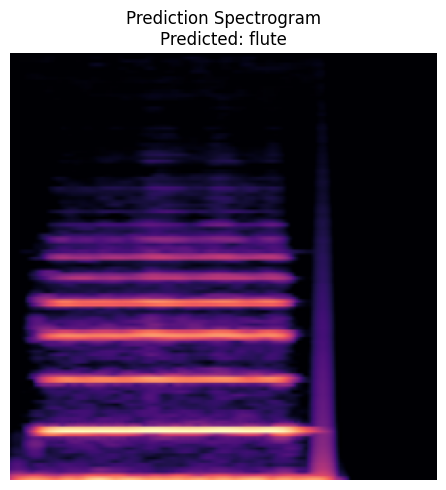

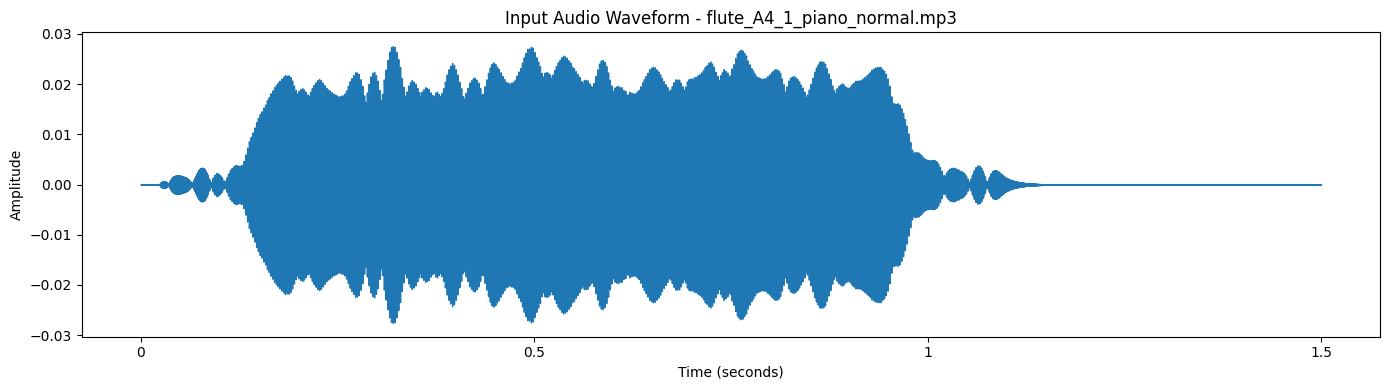

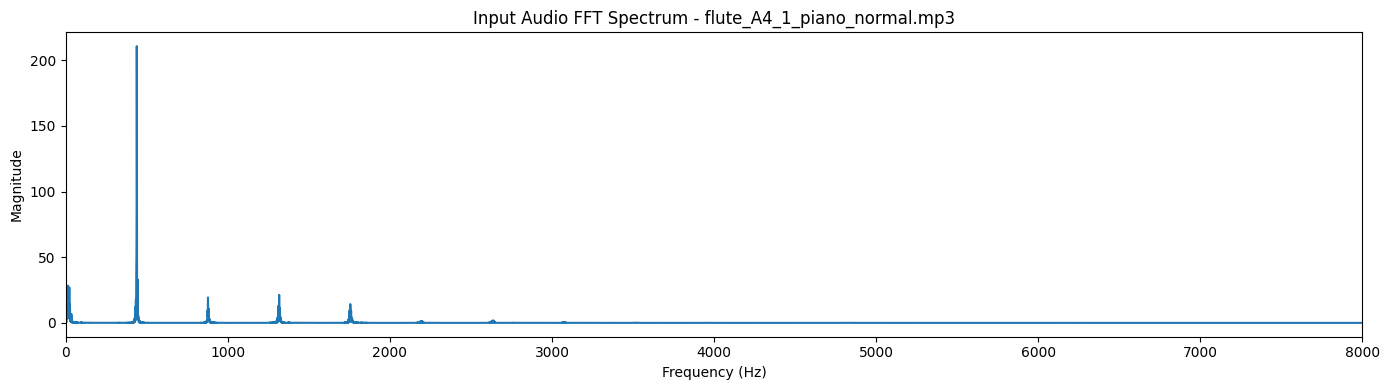

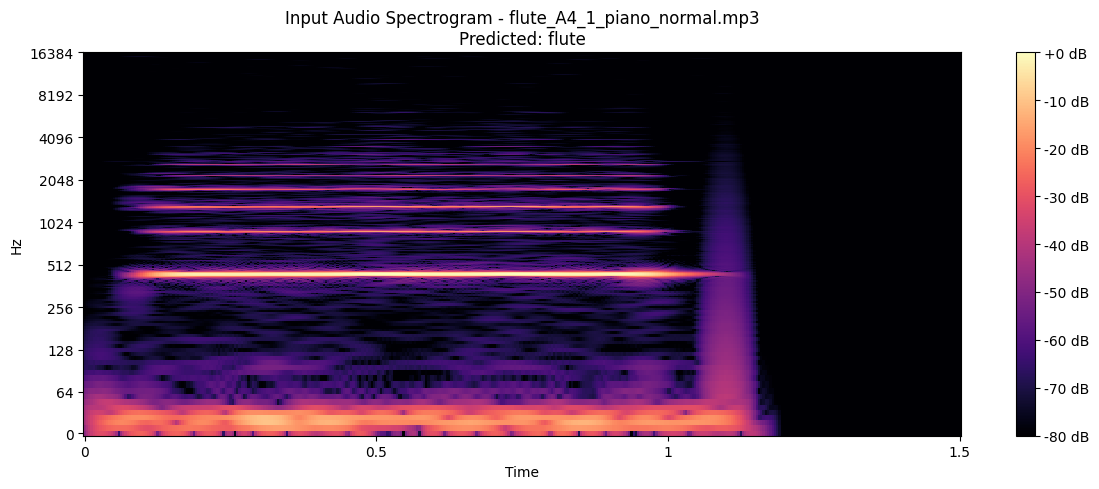

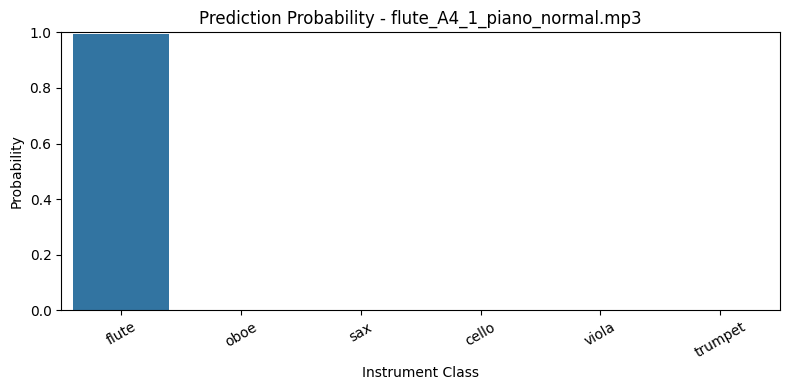


 예측 클래스:  flute

 클래스 별 예측 활률: 
flute : 0.9943
oboe : 0.0031
sax : 0.0020
cello : 0.0003
viola : 0.0001
trumpet : 0.0001


In [36]:
# 22. 신규 오디오 절대경로로 입력

NEW_AUDIO_ABSOLUTE_PATH = r"\home\pc\study_archive\ai\2026\sound\audio\flute\flute_A4_1_piano_normal.mp3".replace("\\", "/")

print_section_title("신규 오디오 예측 준비")
print("절대경로 입력 예시: ", NEW_AUDIO_ABSOLUTE_PATH)

if os.path.exists(NEW_AUDIO_ABSOLUTE_PATH):
  predicted_classes, probs_dict = predict_instrument_from_audio_absolute_path(
    audio_path=NEW_AUDIO_ABSOLUTE_PATH,
    model=model,
    class_indices=train_generator.class_indices,
    save_temp_img=False
  )

  print("\n 예측 클래스: ", predicted_classes)
  print("\n 클래스 별 예측 활률: ")
  for cls, prob in sorted(probs_dict.items(), key=lambda x: x[1], reverse=True):
    print(f"{cls} : {prob:.4f}")
else:
  print("NEW_AUDIO_ABSOLUTE_PATH를 실제 존재하는 절대경로로 수정한 뒤 예측을 실행하세요.")